--- DATASET LOADED ---
Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



--- DATA INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

--- STATISTICAL SUMMARY ---


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010



--- FEATURES & TARGET ---
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: MedHouseVal

Training Set: (16512, 8)
Testing Set: (4128, 8)

--- MODEL TRAINED SUCCESSFULLY ---

--- PREDICTION COMPARISON (First 5 Rows) ---


,Actual,Predicted
20046,0.47700,0.719123
3024,0.45800,1.764017
15663,5.00001,2.709659
20484,2.18600,2.838926
9814,2.78000,2.604657



--- EVALUATION REPORT ---
Mean Absolute Error (MAE): 0.5332
Root Mean Squared Error (RMSE): 0.7456


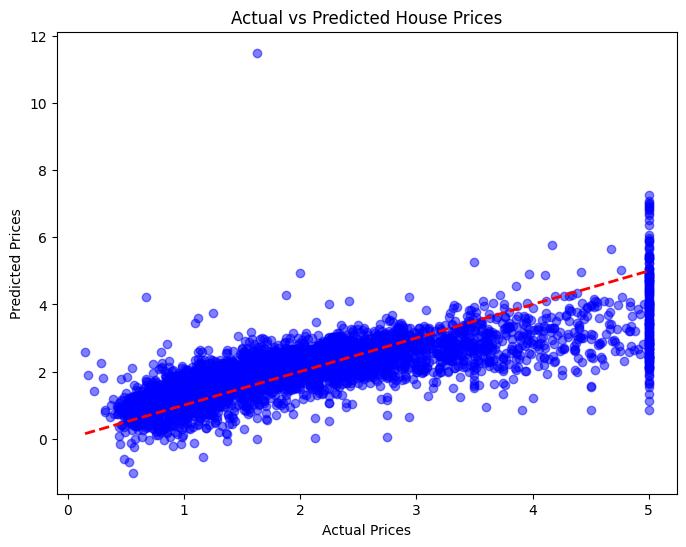


--- FEATURE IMPORTANCE (Coefficients) ---


,Feature,Coefficient
3,AveBedrms,0.783145
0,MedInc,0.448675
1,HouseAge,0.009724
4,Population,-0.000002
5,AveOccup,-0.003526
2,AveRooms,-0.123323
6,Latitude,-0.419792
7,Longitude,-0.433708


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Load the Dataset
# Using the standard California Housing dataset from Scikit-learn
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print("--- DATASET LOADED ---")
print(f"Shape: {df.shape}")
display(df.head())

# 2. Basic Inspection
print("\n--- DATA INFO ---")
df.info()
print("\n--- STATISTICAL SUMMARY ---")
display(df.describe())

# 3. Separate Features (X) and Target (y)
# Target is 'MedHouseVal' (Median House Value)
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

print("\n--- FEATURES & TARGET ---")
print(f"Features: {list(X.columns)}")
print(f"Target: MedHouseVal")

# 4. Train-Test Split
# 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining Set: {X_train.shape}")
print(f"Testing Set: {X_test.shape}")

# 5. Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)
print("\n--- MODEL TRAINED SUCCESSFULLY ---")

# 6. Predictions
y_pred = model.predict(X_test)

# Comparison Table (Actual vs Predicted)
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\n--- PREDICTION COMPARISON (First 5 Rows) ---")
display(comparison.head())

# 7. Evaluation Metrics (MAE & RMSE)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n--- EVALUATION REPORT ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# 8. Plot Predicted vs Actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Diagonal line (Perfect fit)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

# 9. Interpret Coefficients
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)

print("\n--- FEATURE IMPORTANCE (Coefficients) ---")
display(coefficients)